In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import warnings 

In [4]:
warnings.filterwarnings("ignore")

In [5]:
dataset = pd.read_csv("kidney_disease.csv")

In [6]:
dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [7]:
# first we are going to do data pre-processing 

In [8]:
# in this we have 2 impo step 1) check for missing or null value 2) check for outlayres

In [9]:
# Missing or null value

In [10]:
dataset.isna().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [11]:
dataset.isna()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
397,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
398,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
def QuanQual(dataset):

    Qual = []
    Quan = []
    for columnName in dataset.columns:
        if(dataset[columnName].dtype == 'O'):
           Qual.append(columnName)
        else:
           Quan.append(columnName)
    return Quan,Qual


In [13]:
QuanQual(dataset)

(['id',
  'age',
  'bp',
  'sg',
  'al',
  'su',
  'bgr',
  'bu',
  'sc',
  'sod',
  'pot',
  'hemo'],
 ['rbc',
  'pc',
  'pcc',
  'ba',
  'pcv',
  'wc',
  'rc',
  'htn',
  'dm',
  'cad',
  'appet',
  'pe',
  'ane',
  'classification'])

In [14]:
quan,qual = QuanQual(dataset)

In [15]:
dataset[quan]

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4
1,1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3
2,2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6
3,3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2
4,4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.9,15.7
396,396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,16.5
397,397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.4,15.8
398,398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,14.2


In [16]:
dataset[qual]

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,NaN,normal,notpresent,notpresent,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,NaN,normal,notpresent,notpresent,38,6000,NaN,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,47,6700,4.9,no,no,no,good,no,no,notckd
396,normal,normal,notpresent,notpresent,54,7800,6.2,no,no,no,good,no,no,notckd
397,normal,normal,notpresent,notpresent,49,6600,5.4,no,no,no,good,no,no,notckd
398,normal,normal,notpresent,notpresent,51,7200,5.9,no,no,no,good,no,no,notckd


In [19]:
import numpy as np
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(dataset[quan])
df = imp.transform(dataset[quan])

In [20]:
df = pd.DataFrame(df,columns = quan)

In [21]:
imp

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [22]:
df

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0.0,48.0,80.0,1.020,1.0,0.0,121.000000,36.0,1.2,137.528754,4.627244,15.4
1,1.0,7.0,50.0,1.020,4.0,0.0,148.036517,18.0,0.8,137.528754,4.627244,11.3
2,2.0,62.0,80.0,1.010,2.0,3.0,423.000000,53.0,1.8,137.528754,4.627244,9.6
3,3.0,48.0,70.0,1.005,4.0,0.0,117.000000,56.0,3.8,111.000000,2.500000,11.2
4,4.0,51.0,80.0,1.010,2.0,0.0,106.000000,26.0,1.4,137.528754,4.627244,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395.0,55.0,80.0,1.020,0.0,0.0,140.000000,49.0,0.5,150.000000,4.900000,15.7
396,396.0,42.0,70.0,1.025,0.0,0.0,75.000000,31.0,1.2,141.000000,3.500000,16.5
397,397.0,12.0,80.0,1.020,0.0,0.0,100.000000,26.0,0.6,137.000000,4.400000,15.8
398,398.0,17.0,60.0,1.025,0.0,0.0,114.000000,50.0,1.0,135.000000,4.900000,14.2


In [23]:
dataset[quan] = df

In [24]:
dataset[quan]

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0.0,48.0,80.0,1.020,1.0,0.0,121.000000,36.0,1.2,137.528754,4.627244,15.4
1,1.0,7.0,50.0,1.020,4.0,0.0,148.036517,18.0,0.8,137.528754,4.627244,11.3
2,2.0,62.0,80.0,1.010,2.0,3.0,423.000000,53.0,1.8,137.528754,4.627244,9.6
3,3.0,48.0,70.0,1.005,4.0,0.0,117.000000,56.0,3.8,111.000000,2.500000,11.2
4,4.0,51.0,80.0,1.010,2.0,0.0,106.000000,26.0,1.4,137.528754,4.627244,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395.0,55.0,80.0,1.020,0.0,0.0,140.000000,49.0,0.5,150.000000,4.900000,15.7
396,396.0,42.0,70.0,1.025,0.0,0.0,75.000000,31.0,1.2,141.000000,3.500000,16.5
397,397.0,12.0,80.0,1.020,0.0,0.0,100.000000,26.0,0.6,137.000000,4.400000,15.8
398,398.0,17.0,60.0,1.025,0.0,0.0,114.000000,50.0,1.0,135.000000,4.900000,14.2


In [25]:
import numpy as np
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imp.fit(dataset[qual])
dt = imp.transform(dataset[qual])

In [26]:
dt = pd.DataFrame(dt,columns = qual)

In [27]:
imp

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [28]:
dt

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,normal,normal,notpresent,notpresent,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,normal,normal,notpresent,notpresent,38,6000,5.2,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,47,6700,4.9,no,no,no,good,no,no,notckd
396,normal,normal,notpresent,notpresent,54,7800,6.2,no,no,no,good,no,no,notckd
397,normal,normal,notpresent,notpresent,49,6600,5.4,no,no,no,good,no,no,notckd
398,normal,normal,notpresent,notpresent,51,7200,5.9,no,no,no,good,no,no,notckd


In [29]:
dataset[qual] = dt

In [30]:
dataset[qual]

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,normal,normal,notpresent,notpresent,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,normal,normal,notpresent,notpresent,38,6000,5.2,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,47,6700,4.9,no,no,no,good,no,no,notckd
396,normal,normal,notpresent,notpresent,54,7800,6.2,no,no,no,good,no,no,notckd
397,normal,normal,notpresent,notpresent,49,6600,5.4,no,no,no,good,no,no,notckd
398,normal,normal,notpresent,notpresent,51,7200,5.9,no,no,no,good,no,no,notckd


In [31]:
dataset.isna().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [32]:
# finding outliers

In [33]:
# using matlab

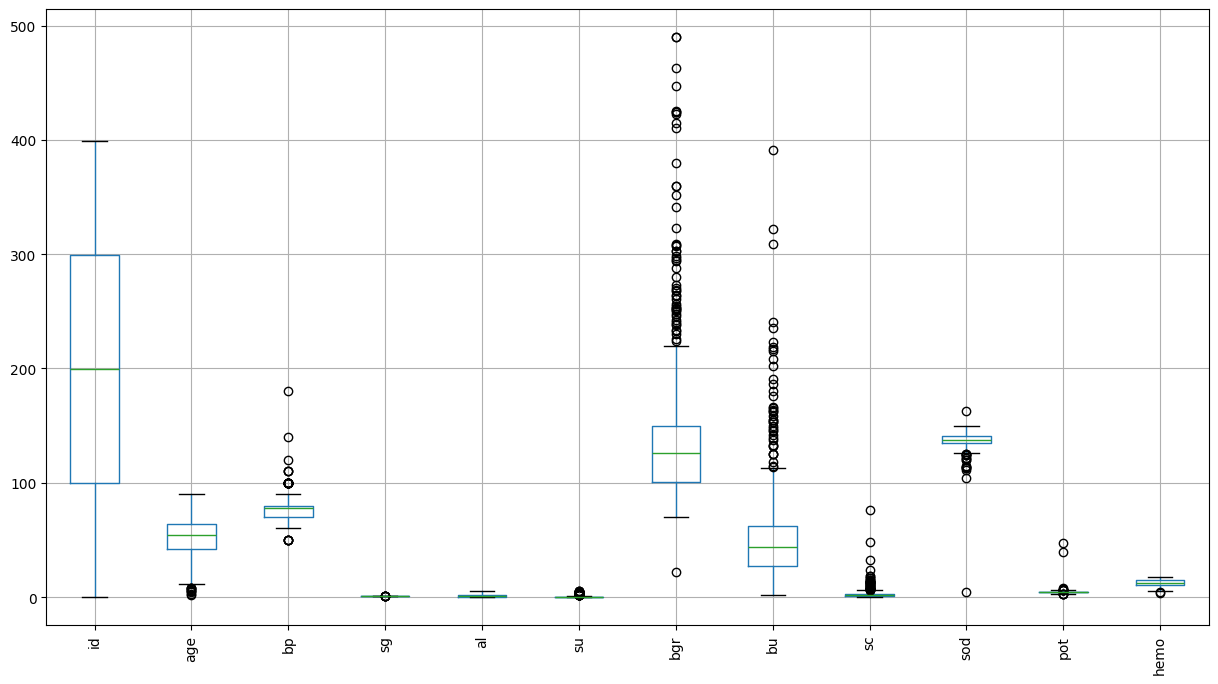

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

dataset.boxplot(figsize=(15,8))
plt.xticks(rotation=90)
plt.show()

In [35]:
#Using normal way

In [36]:
dataset.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,16.974966,13.476298,0.005369,1.272318,1.029487,74.782634,49.285887,5.617490,9.204273,2.819783,2.716171
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.015000,0.000000,0.000000,101.000000,27.000000,0.900000,135.000000,4.000000,10.875000
50%,199.500000,54.000000,78.234536,1.017408,1.000000,0.000000,126.000000,44.000000,1.400000,137.528754,4.627244,12.526437
75%,299.250000,64.000000,80.000000,1.020000,2.000000,0.450142,150.000000,61.750000,3.072454,141.000000,4.800000,14.625000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [37]:
#to form table

In [38]:
descriptive = pd.DataFrame()

In [39]:
descriptive

""


In [40]:
descriptive=pd.DataFrame(index=["Q1:25%","Q3:75%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)

for ColumnName in quan:
        
    descriptive[ColumnName]["Q1:25%"]=dataset.describe()[ColumnName]["25%"]
    descriptive[ColumnName]["Q3:75%"]=dataset.describe()[ColumnName]["75%"]
    descriptive[ColumnName]["IQR"]=descriptive[ColumnName]["Q3:75%"] - descriptive[ColumnName]["Q1:25%"]
    descriptive[ColumnName]["1.5rule"]= 1.5 * descriptive[ColumnName]["IQR"] 
    descriptive[ColumnName]["Lesser"]=descriptive[ColumnName]["Q1:25%"] - descriptive[ColumnName]["1.5rule"]
    descriptive[ColumnName]["Greater"]=descriptive[ColumnName]["Q3:75%"] + descriptive[ColumnName]["1.5rule"]
    descriptive[ColumnName]["Min"]=dataset[ColumnName].min()
    descriptive[ColumnName]["Max"]=dataset[ColumnName].max()

In [41]:
descriptive

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
Q1:25%,99.75,42.0,70.0,1.015,0.0,0.0,101.0,27.0,0.9,135.0,4.0,10.875
Q3:75%,299.25,64.0,80.0,1.02,2.0,0.450142,150.0,61.75,3.072454,141.0,4.8,14.625
IQR,199.5,22.0,10.0,0.005,2.0,0.450142,49.0,34.75,2.172454,6.0,0.8,3.75
1.5rule,299.25,33.0,15.0,0.0075,3.0,0.675214,73.5,52.125,3.258681,9.0,1.2,5.625
Lesser,-199.5,9.0,55.0,1.0075,-3.0,-0.675214,27.5,-25.125,-2.358681,126.0,2.8,5.25
Greater,598.5,97.0,95.0,1.0275,5.0,1.125356,223.5,113.875,6.331136,150.0,6.0,20.25
Min,0.0,2.0,50.0,1.005,0.0,0.0,22.0,1.5,0.4,4.5,2.5,3.1
Max,399.0,90.0,180.0,1.025,5.0,5.0,490.0,391.0,76.0,163.0,47.0,17.8


In [42]:
# to find lesser and greater outliars

In [43]:
Lesser=[]
Greater=[]

for ColumnName in quan:
    if(descriptive[ColumnName]["Min"]<descriptive[ColumnName]["Lesser"]):
        Lesser.append(ColumnName)
    if(descriptive[ColumnName]["Max"]<descriptive[ColumnName]["Greater"]):
        Greater.append(ColumnName)


In [44]:
Lesser

['age', 'bp', 'sg', 'bgr', 'sod', 'pot', 'hemo']

In [45]:
Greater

['id', 'age', 'sg', 'hemo']

In [46]:
# since this is a medical data this outliars cannot be considered as error so im not correcting it 

In [47]:
# just to know I'm correcting it

In [52]:
for ColumnName in Lesser:
    
    dataset[ColumnName][dataset[ColumnName]<descriptive[ColumnName]["Lesser"]]=descriptive[ColumnName]["Lesser"]
    
for ColumnName in Greater:
    
    dataset[ColumnName][dataset[ColumnName]<descriptive[ColumnName]["Greater"]]=descriptive[ColumnName]["Greater"]



In [56]:
descriptive=pd.DataFrame(index=["Q1:25%","Q3:75%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)

for ColumnName in quan:
        
    descriptive[ColumnName]["Q1:25%"]=dataset.describe()[ColumnName]["25%"]
    descriptive[ColumnName]["Q3:75%"]=dataset.describe()[ColumnName]["75%"]
    descriptive[ColumnName]["IQR"]=descriptive[ColumnName]["Q3:75%"] - descriptive[ColumnName]["Q1:25%"]
    descriptive[ColumnName]["1.5rule"]= 1.5 * descriptive[ColumnName]["IQR"] 
    descriptive[ColumnName]["Lesser"]=descriptive[ColumnName]["Q1:25%"] - descriptive[ColumnName]["1.5rule"]
    descriptive[ColumnName]["Greater"]=descriptive[ColumnName]["Q3:75%"] + descriptive[ColumnName]["1.5rule"]
    descriptive[ColumnName]["Min"]=dataset[ColumnName].min()
    descriptive[ColumnName]["Max"]=dataset[ColumnName].max()

In [57]:
descriptive

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
Q1:25%,598.5,97.0,70.0,1.0275,0.0,0.0,101.0,27.0,0.9,135.0,4.0,20.25
Q3:75%,598.5,97.0,80.0,1.0275,2.0,0.450142,150.0,61.75,3.072454,141.0,4.8,20.25
IQR,0.0,0.0,10.0,0.0,2.0,0.450142,49.0,34.75,2.172454,6.0,0.8,0.0
1.5rule,0.0,0.0,15.0,0.0,3.0,0.675214,73.5,52.125,3.258681,9.0,1.2,0.0
Lesser,598.5,97.0,55.0,1.0275,-3.0,-0.675214,27.5,-25.125,-2.358681,126.0,2.8,20.25
Greater,598.5,97.0,95.0,1.0275,5.0,1.125356,223.5,113.875,6.331136,150.0,6.0,20.25
Min,598.5,97.0,55.0,1.0275,0.0,0.0,27.5,1.5,0.4,126.0,2.8,20.25
Max,598.5,97.0,180.0,1.0275,5.0,5.0,490.0,391.0,76.0,163.0,47.0,20.25


In [58]:
Lesser=[]
Greater=[]

for ColumnName in quan:
    if(descriptive[ColumnName]["Min"]<descriptive[ColumnName]["Lesser"]):
        Lesser.append(ColumnName)
    if(descriptive[ColumnName]["Max"]<descriptive[ColumnName]["Greater"]):
        Greater.append(ColumnName)


In [60]:
Greater

[]

In [59]:
Lesser

[]